In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import seaborn as sns
import itertools
from colour import Color
from datetime import date
import tifffile
import scipy  as spy
from skimage import filters

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2022-05-24


'2022-05-24'

In [6]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
path = Path(askdirectory)
path

WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter')

In [15]:
folder_dates = [x for x in path.iterdir() if x.is_dir() if str(x).rfind('-analyze') != -1]
folders = []
for i in folder_dates:
    folders0 = [x for x in i.iterdir() if x.is_dir() if str(x).rfind('yes') != -1]
    
    for j in folders0:
        folders = folders + [x for x in j.iterdir() if x.is_dir() if str(x).rfind('Kymo') != -1]

folders

[WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol-analyze/CH1_DCX2nM_TypeWT_tax0uM-yes/Kymographs-1-Stream_ctl_Composite-GFP'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol-analyze/CH1_DCX2nM_TypeWT_tax0uM-yes/Kymographs-1-Stream_ctl_Composite_RFP'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-18_flowin_phalloidin_newtaxol-analyze/CH2_DCX2nM_TypeWT_tax0.1uM-yes/Kymographs-1-Stream_Composite_final_GFP'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-18_flowin_phalloidin_newtaxol-analyze/CH2_DCX2nM_TypeWT_tax0.1uM-yes/Kymographs-1-Stream_Composite_RFP'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-18_flowin_phalloidin_newtaxol-analyze/CH3_DCX2nM_TypeWT_tax0.3uM-yes/Kymographs-1-Stream_Composite_final_GFP'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/202

In [75]:
GFP_files = []
RFP_files = []
for i in folders:
    GFP_files = GFP_files + [x for x in i.iterdir() if x.is_file() if str(x).rfind('GFP') != -1]
    RFP_files = RFP_files + [x for x in i.iterdir() if x.is_file() if str(x).rfind('RFP') != -1]
GFP_files[0],GFP_files[-1],RFP_files[0],RFP_files[-1]

(WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol-analyze/CH1_DCX2nM_TypeWT_tax0uM-yes/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_001_0500-0385-0416.tif'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol-analyze/CH4_DCX2nM_TypeWT_tax0.1uM-yes/Kymographs-1-Stream_Composite_GFP/Kymograph_014_0252-0213-0069.tif'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol-analyze/CH1_DCX2nM_TypeWT_tax0uM-yes/Kymographs-1-Stream_ctl_Composite_RFP/Kymograph_001_0124-0290-0217.tif'),
 WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol-analyze/CH4_DCX2nM_TypeWT_tax0.1uM-yes/Kymographs-1-Stream_Composite_RFP/Kymograph_010_0292-0372-0273.tif'))

## Get Metadata ##

In [42]:
DCXconc = '[DCX] ' r'$(n M)$'

Type = 'DCX Type'

taxol = '[Taxol] ' r'$(\mu M)$'
taxolnM = '[Taxol] ' r'$(n M)$'

In [109]:
def metadata(file):

    i = file
    dateloc = str(i).rfind("2022")

    CHloc = str(i).find("CH")
    CHlocend = str(i).find('_', CHloc)

    taxloc = str(i).rfind('tax')
    taxlocend = str(i).find('uM', taxloc)

    DCXloc = str(i).rfind('DCX')
    DCXlocend = str(i).find('nM', DCXloc)

    dcxtypeloc = str(i).find("Type")
    dcxtypelocend = str(i).find('_', dcxtypeloc)

    date = [str(i)[dateloc : dateloc+10]]
    ch = [str(i)[CHloc+2:CHlocend]]
    conc_tax = [float(str(i)[taxloc+3:taxlocend])]
    conc_DCX = [float(str(i)[DCXloc+3:DCXlocend])]
    DCX_type = [str(i)[dcxtypeloc+4:dcxtypelocend]]
    
    filename = i.stem
    
    if str(i).rfind('GFP') != -1:
        Channel = 'GFP'
    if str(i).rfind('RFP') != -1:
        Channel = 'RFP'
    
    MD = pd.DataFrame({'Date': date, 'Filename': filename, 'CH': ch, taxol: conc_tax, DCXconc: conc_DCX, Type: DCX_type, 'Channel': Channel})

    return MD

In [110]:
metadata(GFP_files[0])

,Date,Filename,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type,Channel
0,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP


## Open kymograph ##

In [111]:
kymoR = tifffile.imread(GFP_files[0])
kymoG = tifffile.imread(RFP_files[0])

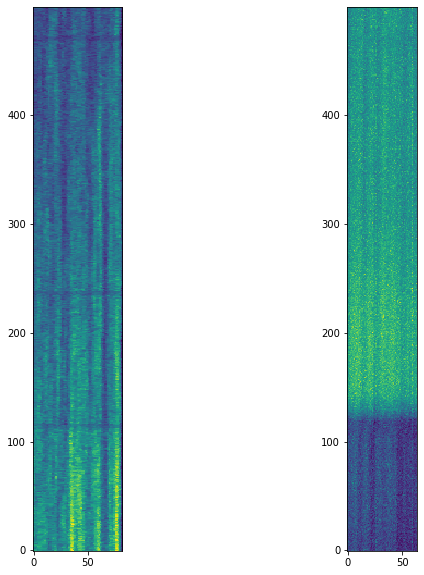

In [112]:
fig, ax = plt.subplots(1,2,figsize=(10,10))

ax[0].imshow(kymoR, interpolation='none', origin=[0, 0], cmap='viridis')
ax[1].imshow(kymoG, interpolation='none', origin=[0, 0], cmap='viridis')

In [113]:
def kymo_intensity(file,roll):
    
    md = metadata(file)
    
    kymo = tifffile.imread(file)
    mean_kymo = np.mean(kymo, axis=1)
    time = np.arange(len(mean_kymo))/10
    result0 = pd.DataFrame({'Time (s)': time, 'Intensity': mean_kymo})
    
    t= len(time)
    md = md.loc[md.index.repeat(t)].reset_index(drop=True) 
    result = pd.concat([md, result0], axis=1)
    
    result['Rolling Intensity'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).mean()
    result['Rolling Intensity std'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).std()
        
    return result

In [126]:
roll = 10

In [123]:
results_GFP = pd.DataFrame(columns=[] , index=[])
for i in GFP_files:
    result0 = kymo_intensity(i,roll)
    results_GFP = pd.concat([results_GFP, result0])

array = results_GFP['Intensity'].values
results_GFP['Normal Intensity'] =  (array - min(array)) / (max(array) - min(array))

array = results_GFP['Rolling Intensity'].values
results_GFP['Normal Rolling Intensity'] =  (array - min(array)) / (max(array) - min(array))
results_GFP['Normal Rolling Intensity std'] = results_GFP['Rolling Intensity std']/(max(array) - min(array)) 
    
results_GFP

,Date,Filename,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type,Channel,Time (s),Intensity,Rolling Intensity,Rolling Intensity std,Normal Intensity,Normal Rolling Intensity,Normal Rolling Intensity std
0,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP,0.0,98.353659,95.909756,1.695705,0.832044,0.841068,0.015497
1,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP,0.1,94.231707,95.953252,1.520422,0.795995,0.841466,0.013895
2,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP,0.2,95.646341,95.472125,1.883291,0.808367,0.837069,0.017211
3,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP,0.3,94.536585,95.533537,1.752219,0.798662,0.837630,0.016013
4,2022-05-11,Kymograph_001_0500-0385-0416,1,0.0,2.0,WT,GFP,0.4,96.780488,95.422764,1.672400,0.818286,0.836618,0.015284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2022-05-19,Kymograph_014_0252-0213-0069,4,0.1,2.0,WT,GFP,49.5,22.375000,23.212500,2.358348,0.167571,0.176692,0.021553
496,2022-05-19,Kymograph_014_0252-0213-0069,4,0.1,2.0,WT,GFP,49.6,23.375000,23.027778,2.423459,0.176316,0.175004,0.022148
497,2022-05-19,Kymograph_014_0252-0213-0069,4,0.1,2.0,WT,GFP,49.7,20.812500,22.742188,2.423480,0.153906,0.172394,0.022148
498,2022-05-19,Kymograph_014_0252-0213-0069,4,0.1,2.0,WT,GFP,49.8,19.812500,22.178571,1.971618,0.145160,0.167243,0.018019


In [124]:
results_RFP = pd.DataFrame(columns=[] , index=[])
for i in RFP_files:
    result0 = kymo_intensity(i,10)
    results_RFP = pd.concat([results_RFP, result0])

In [125]:
grouped_results_RFP = results_RFP.groupby(['Date', 'CH','Time (s)']).mean()
grouped_results_RFP = grouped_results_RFP.reset_index()

array = grouped_results_RFP['Intensity'].values
grouped_results_RFP['Normal Intensity'] =  (array - min(array)) / (max(array) - min(array))

array = grouped_results_RFP['Rolling Intensity'].values
grouped_results_RFP['Normal Rolling Intensity'] =  (array - min(array)) / (max(array) - min(array))
grouped_results_RFP['Normal Rolling Intensity std'] = grouped_results_RFP['Rolling Intensity std']/(max(array) - min(array)) 

grouped_results_RFP

,Date,CH,Time (s),[Taxol] $(\mu M)$,[DCX] $(n M)$,Intensity,Rolling Intensity,Rolling Intensity std,Normal Intensity,Normal Rolling Intensity,Normal Rolling Intensity std
0,2022-05-11,1,0.0,0.0,2.0,606.935434,608.392632,2.743303,0.359484,0.362799,0.005258
1,2022-05-11,1,0.1,0.0,2.0,610.179856,608.380761,2.706759,0.365656,0.362777,0.005188
2,2022-05-11,1,0.2,0.0,2.0,608.386499,608.232684,2.819504,0.362244,0.362493,0.005404
3,2022-05-11,1,0.3,0.0,2.0,607.789762,608.798371,3.209398,0.361109,0.363577,0.006152
4,2022-05-11,1,0.4,0.0,2.0,608.671606,608.738478,3.164488,0.362787,0.363462,0.006065
...,...,...,...,...,...,...,...,...,...,...,...
3995,2022-05-19,4,49.5,0.1,2.0,862.704967,861.400192,3.469424,0.846103,0.847743,0.006650
3996,2022-05-19,4,49.6,0.1,2.0,860.713563,861.401291,3.569798,0.842315,0.847745,0.006842
3997,2022-05-19,4,49.7,0.1,2.0,859.637433,861.133267,3.517071,0.840267,0.847231,0.006741
3998,2022-05-19,4,49.8,0.1,2.0,860.298897,860.567329,3.276464,0.841526,0.846146,0.006280


## Save Data ##

In [130]:
newdirectory = str(path)+'//Photobleaching_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets')

In [134]:
results_GFP.to_csv(newmydir/('results_GFP_analysed-on_'+date_today+'.csv'), encoding='utf-8', index=False)
grouped_results_RFP.to_csv(newmydir/('grouped_results_RFP_analysed-on_'+date_today+'.csv'), encoding='utf-8', index=False)

## Open saved data and plot ##

In [135]:
askfileGFP = filedialog.askopenfilename()
GFP = pd.read_csv(askfileGFP, encoding='utf-8')

In [136]:
askfileRFP = filedialog.askopenfilename()
RFP = pd.read_csv(askfileRFP, encoding='utf-8')

In [164]:
askfileGFP = Path(askfileGFP)
newdirectory = str(askfileGFP.parents[0])+'//Plots'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('C:/Users/Brouhard Lab/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/Plots')

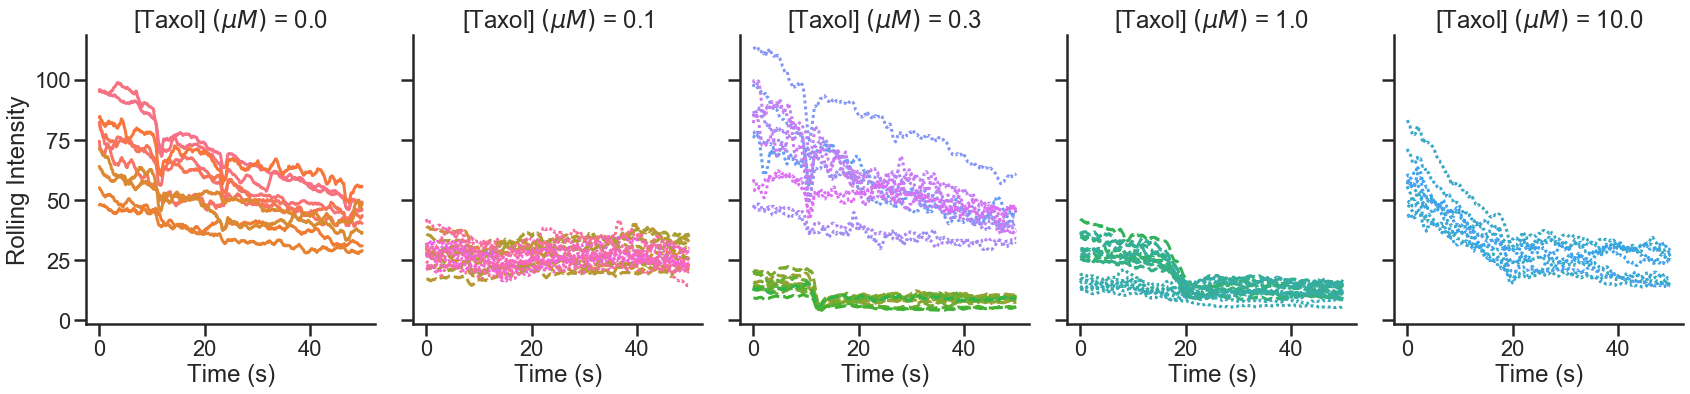

In [174]:

sns.relplot(
    data=GFP, x="Time (s)", y="Rolling Intensity", col=taxol,
    hue="Filename", style="Date", kind="line",legend=False,
    height=6, aspect=0.8
)

sns.set_style("ticks")
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(newmydir/('GFP'+date_today+'.pdf'))
plt.savefig(newmydir/('GFP'+date_today+'.png'))

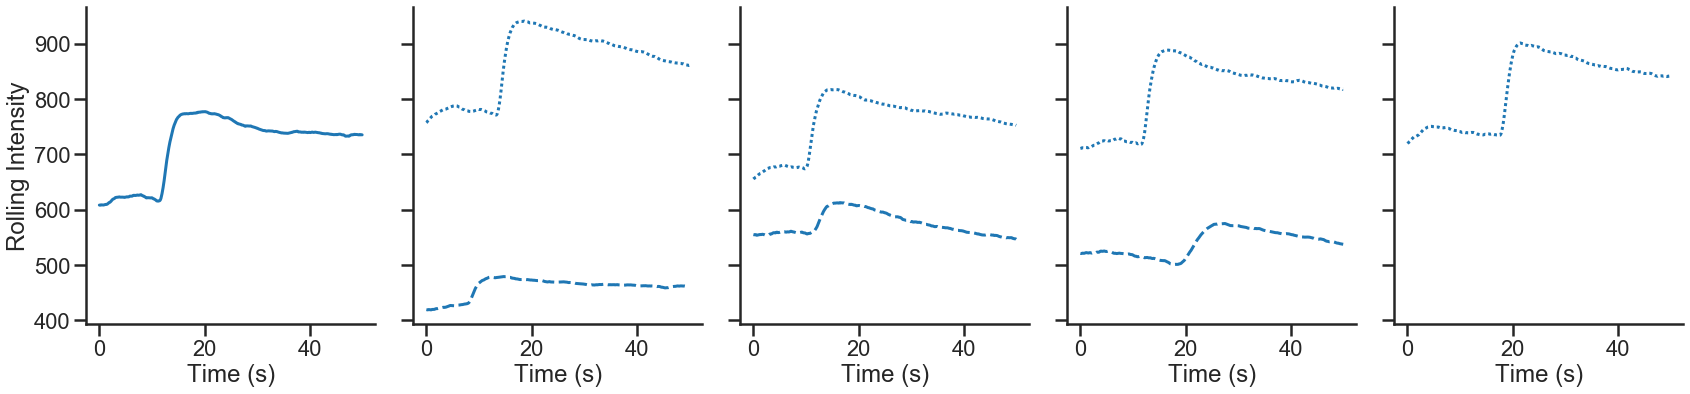

In [175]:
ax = sns.relplot(
    data=RFP, x="Time (s)", y="Rolling Intensity", col=taxol,
    style="Date", kind="line",legend=False,
    height=6, aspect=0.8
)

ax.set_titles("")

sns.set_style("ticks")
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(newmydir/('RFP'+date_today+'.pdf'))
plt.savefig(newmydir/('RFP'+date_today+'.png'))

In [ ]:
def get_values(data):
    x = data['Time (s)'].values
    mean = data['Normal Rolling Intensity'].values
    std = data['Normal Rolling Intensity std'].values
    return x, mean, std

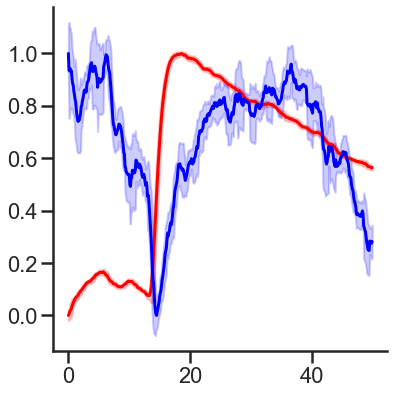

In [257]:
plt.figure(figsize=(6, 6))

x, mean, std = get_values(allRFP)
plt.plot(x, mean, 'r-')
plt.fill_between(x, mean - std, mean + std, color='r', alpha=0.2)

x, mean, std = get_values(allGFP)
plt.plot(x, mean, 'b-')
plt.fill_between(x, mean - std, mean + std, color='b', alpha=0.2)


sns.set_style("ticks")
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.tight_layout()

## Save data ##

In [258]:
data

,Time (s),Intensity,Normal Intensity,Rolling Intensity,Rolling Intensity std,Normal Rolling Intensity,Normal Rolling Intensity std,Channel,n,Date,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type
0,0.0,753.073634,0.000000,757.329984,3.813510,0.000000,0.020781,RFP,10,2022-05-19,4,0.1,2.0,WT
1,0.1,754.383609,0.006876,758.136316,3.941486,0.004394,0.021479,RFP,10,2022-05-19,4,0.1,2.0,WT
2,0.2,756.667527,0.018864,759.688821,5.460586,0.012854,0.029757,RFP,10,2022-05-19,4,0.1,2.0,WT
3,0.3,761.215708,0.042736,760.617784,5.697549,0.017917,0.031048,RFP,10,2022-05-19,4,0.1,2.0,WT
4,0.4,761.309444,0.043228,761.276988,5.684650,0.021509,0.030978,RFP,10,2022-05-19,4,0.1,2.0,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,49.5,23.487676,0.276096,23.568535,0.386492,0.283992,0.050968,GFP,14,2022-05-19,4,0.1,2.0,WT
996,49.6,23.398452,0.266520,23.561771,0.409308,0.283100,0.053977,GFP,14,2022-05-19,4,0.1,2.0,WT
997,49.7,23.830152,0.312853,23.525738,0.422033,0.278348,0.055655,GFP,14,2022-05-19,4,0.1,2.0,WT
998,49.8,23.596465,0.287772,23.505150,0.451488,0.275633,0.059539,GFP,14,2022-05-19,4,0.1,2.0,WT


In [259]:
newdirectory = str(path.parents[1])+'//Photobleaching_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [260]:
data.to_csv(path/(date+'_CH'+ch+'_phototbleach_analysed-on_'+date_today +'.csv'), encoding='utf-8', index=False)
data.to_csv(newmydir/(date+'_CH'+ch+'_phototbleach_analysed-on_'+date_today+'.csv'), encoding='utf-8', index=False)

## Join Data ##

In [261]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [262]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-11_CH1_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH2_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH3_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH4_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH1_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH2_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH3_phototbleach_a

In [331]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata[taxolnM] = joindata[taxol]*1000
joindata[taxolnM] = joindata[taxolnM].astype('int', copy=False)
joindata[taxolnM] = joindata[taxolnM].astype('str', copy=False)
joindata.to_csv(path/('jointdata-photobleach_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Time (s),Intensity,Normal Intensity,Rolling Intensity,Rolling Intensity std,Normal Rolling Intensity,Normal Rolling Intensity std,Channel,n,Date,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type,[Taxol] $(n M)$
0,0.0,606.935434,0.005855,608.392632,1.199887,0.000947,0.007103,RFP,10,2022-05-11,1,0.0,2.0,WT,0
1,0.1,610.179856,0.024518,608.380761,1.073605,0.000877,0.006355,RFP,10,2022-05-11,1,0.0,2.0,WT,0
2,0.2,608.386499,0.014202,608.232684,1.055467,0.000000,0.006248,RFP,10,2022-05-11,1,0.0,2.0,WT,0
3,0.3,607.789762,0.010769,608.798371,1.874801,0.003349,0.011098,RFP,10,2022-05-11,1,0.0,2.0,WT,0
4,0.4,608.671606,0.015842,608.738478,1.762896,0.002994,0.010436,RFP,10,2022-05-11,1,0.0,2.0,WT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,49.5,23.487676,0.276096,23.568535,0.386492,0.283992,0.050968,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7996,49.6,23.398452,0.266520,23.561771,0.409308,0.283100,0.053977,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7997,49.7,23.830152,0.312853,23.525738,0.422033,0.278348,0.055655,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7998,49.8,23.596465,0.287772,23.505150,0.451488,0.275633,0.059539,GFP,14,2022-05-19,4,0.1,2.0,WT,100


## Plot ##

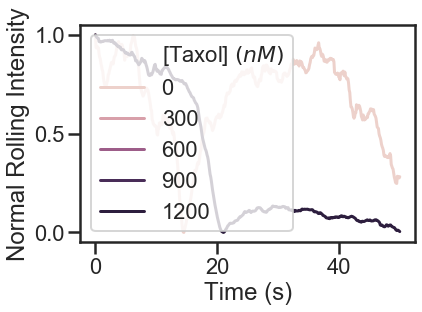

In [334]:
sns.lineplot(data=joindataGFP, x="Time (s)", y="Normal Rolling Intensity", hue=taxolnM)

In [332]:
joindataGFP = joindata[(joindata['Channel']=='GFP') & (joindata['CH']==4)]

In [333]:
joindataGFP[taxolnM].unique()

array(['1000', '100'], dtype=object)